# Semantic Mapping of Mental Health Survey Questions

## 1. Overview

This notebook implements **Method 1 (Baseline): Semantic Mapping** for the mental health dimension reduction project.

The goal of this method is to map diverse mental health survey questions onto a shared set of **high-level wellness dimensions** (Emotional, Social, Physical, Occupational, Intellectual, Spiritual, Environmental, Financial) using a **concept-driven, label-free approach**.

Rather than learning dimension representations from labeled data, this approach begins by defining the *same set of wellness dimension types* using **natural-language definitions generated by multiple large language models (LLMs)**.  
Each LLM is prompted with an identical instruction, producing alternative textual realizations of the same conceptual dimensions.

These model-generated dimension definitions serve as **semantic prototypes (anchors)**. Both survey questions and dimension prototypes are embedded into a shared semantic space using a pretrained sentence encoder. Survey questions are then mapped back to the wellness dimensions by measuring cosine similarity to the corresponding prototypes, allowing each question to be assigned to one or more dimensions.

By holding the dimension types fixed while varying the language used to define them, this method enables controlled comparisons of how different LLM-generated definitions influence semantic alignment and downstream mappings. Semantic mapping thus provides a principled bridge between conceptual wellness frameworks and data-driven analysis.

## 2. Data

Each data point corresponds to a **single survey question**, represented with:
- `qid`: the original item identifier (e.g., PSQI_5_3, PSS_12)
- `dataset`: the source questionnaire or scale
- `text`: the question text

All questions are consolidated into a canonical dataset (`questions_master`) during preprocessing to ensure:
- No modification of raw source files
- Consistent identifiers across methods
- Reproducibility across models and experiments


In [ ]:
from pathlib import Path
from mhdr.dataloader.io import read_csv
INPUT_DIR = Path.cwd() / "input"
OUTPUT_DIR = Path.cwd() / "output"
TEMP_DIR = Path.cwd() / "temp"




,qid,dataset,text
0,CD_RISC_1,CD-RISC,I am able to adapt when changes occur.
1,CD_RISC_2,CD-RISC,I have one close and secure relationship.
2,CD_RISC_3,CD-RISC,Sometimes fate or God helps me.
3,CD_RISC_4,CD-RISC,I can deal with whatever comes my way.
4,CD_RISC_5,CD-RISC,Past successes give me confidence.


In [2]:
print("Total questions:", len(questions))
questions["dataset"].value_counts()

Total questions: 145


dataset
PWS        36
CD-RISC    25
PERMA      23
PSS        23
UCLA       20
PWB        18
Name: count, dtype: int64

## 3. Dimension
The wellness dimensions used in this project are represented by natural-language definitions generated by multiple large language models (LLMs).
Each model is prompted using the same fixed instruction, ensuring that differences across dimension sets reflect model-specific generation behavior rather than prompt variation.


- `model_name`: the identifier of the large language model used to generate the definition  
- `dim_name`: the name of the wellness dimension (e.g., Emotional, Social, Physical)  
- `dim_text`: the natural-language definition generated for that dimension
A utility function (`load_dimension_sets`) is provided to load this file and group the definitions by model.  
The resulting data structure is a dictionary mapping each model name to a list of its corresponding dimension definitions, for example:

```python
{
  "ChatGPT-5.2": [
    "Emotional: ...",
    "Environmental: ...",
    "Financial: ...",
    "Intellectual: ...",
    "Occupational: ...",
    "Physical: ...",
    "Social: ...",
    "Spiritual: ..."
  ],
  "DeepSeek-V3.2": [...],
  "Llama-4": [...],
  "claude-sonnet-4.5": [...],
  "gemini-3.0-pro": [...]
}
```
Each model-specific dimension set is used independently as a collection of semantic prototypes.
These prototypes are mapped against the survey questions described in Section 2 (Data), enabling controlled comparisons of how different LLM-generated dimension definitions influence downstream question-to-dimension mappings.

In [3]:
from utils import load_dimension_sets
dimension_sets = load_dimension_sets("./dim_definations.csv")
print(dimension_sets)
print(len(dimension_sets), len(dimension_sets["Llama-4"]))

{'ChatGPT-5.2': ['Emotional: The ability to recognize, understand, express, and manage feelings in ways that support resilience, balance, and healthy responses to life events.', 'Environmental: The quality of interaction with surrounding spaces, resources, and conditions that influence comfort, safety, and daily functioning.', 'Financial: The capacity to manage money decisions and resources in ways that support stability, choice, and future needs.', 'Intellectual: The ongoing engagement with learning, curiosity, creativity, and critical thinking to expand understanding and skills.', 'Occupational: The sense of purpose, satisfaction, and alignment experienced through work or meaningful daily roles.', 'Physical: The state of the body and the habits that support energy, strength, mobility, and overall functioning.', 'Social: The ability to build, maintain, and experience supportive relationships and a sense of belonging.', 'Spiritual: The way meaning, values, and connection guide a person

## 4. Semantic Mapping Using LLM-Generated Dimensions

In this stage, we perform semantic mapping between survey questions and
wellness dimensions using the `SemanticMapper` module
(`model/mapping/semantic_mapper.py`).

### Mapping Procedure

For each set of dimension definitions generated by a large language model (LLM),
we independently perform a full semantic mapping process.
This results in **one mapping output per LLM**, allowing us to compare
consistency and variation across models.

The mapping procedure consists of the following steps:

1. **Encoding**
   - Survey questions and wellness dimension definitions are embedded into a
     shared semantic space using a pretrained sentence embedding model
     (`all-MiniLM-L6-v2`).
   - The same encoder is used for both questions and dimensions to ensure
     comparability.

2. **Similarity Computation**
   - For each question, cosine similarity is computed against all dimension
     embeddings, producing a question–dimension similarity matrix.

3. **Margin-Based Assignment**
   - Each question is first assigned to the dimension with the highest
     similarity score.
   - Additional dimensions are included if their similarity scores fall within
     a predefined margin (`delta`) of the top score.
   - This allows a single question to be assigned to **multiple dimensions**
     when semantic overlap exists, reflecting the multifaceted nature of
     mental health constructs.

## Output Structure

Each mapping run produces a table (CSV) where **each row corresponds to one survey question mapped under one LLM-generated dimension set**. Conceptually, each row has the following structure:

```python
{
  "qid": "CD_RISC_1",
  "dataset": "CD-RISC",
  "text": "I am able to adapt when changes occur.",
  "dimension_model": "ChatGPT-5.2",
  "dimensions": ["Emotional", "Spiritual", "Physical"],
  "scores": [0.18, 0.17, 0.16]
}
```
- **`qid`**  
  Unique identifier of the survey question.

- **`dataset`**  
  Source questionnaire (e.g., CD-RISC, PERMA, PSS, UCLA).

- **`text`**  
  Original survey question text.

- **`dimension_model`**  
  The LLM used to generate the wellness dimension definitions for this run.

- **`dimensions`**  
  One or more assigned wellness dimensions.  
  Multiple dimensions may be selected when their similarity scores fall within a margin (Δ) of the best match.

- **`scores`**  
  Cosine similarity scores corresponding to the listed dimensions (same order).


In [4]:
from semantic_mapper import SemanticMapper
DELTA = 0.05
mapper = SemanticMapper(model="all-MiniLM-L6-v2")
mapper.set_questions_df(questions)
all_results = {}

for model_name, dim_list in dimension_sets.items():
    mapper.set_dimensions(
        dim_list,
        dimension_model_name=model_name
    )
    df_map = mapper.map_questions_to_dimensions(delta=DELTA)
    all_results[model_name] = df_map
    mapper.save_mapping_to_csv(df_map, delta=DELTA, out_dir=Path("./temp_result"))


/Users/haikeyu/Desktop/mentalhealth-dimension-reduction/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Analysis: Cross-Model Agreement Using Pairwise Jaccard Similarity

To evaluate whether semantic mappings are stable across different LLM-generated dimension definitions, we compare the dimension assignments produced by five independent definition sets. Each set is generated by a different large language model (LLM), while the embedding model, similarity metric, and decision rule remain fixed.

Rather than requiring full agreement across all models, we focus on **pairwise agreement**, which better reflects whether the resulting mappings are *broadly comparable* across different definition sets.

### Pairwise Jaccard Similarity

For a given survey question, let $$D_i$$ and $$D_j$$ denote the sets of dimensions assigned by two different LLM-generated definition sets. The Jaccard similarity between the two assignments is defined as:

$$
J(D_i, D_j)
=
\frac{|D_i \cap D_j|}{|D_i \cup D_j|}
$$

We compute this score for all unordered pairs of models and report the **mean pairwise Jaccard similarity**:

$$
\bar{J}
=
\frac{2}{K(K-1)}
\sum_{i<j}
\frac{|D_i \cap D_j|}{|D_i \cup D_j|}
$$

where $$K = 5$$ is the number of LLMs, resulting in $$\binom{5}{2} = 10$$ model pairs per question.

This average score captures how similar the dimension assignments are *on average* across models, without requiring strict unanimity.

### Example

Consider a survey question mapped by five different LLM-generated dimension sets:

- Model 1: {Emotional, Social}  
- Model 2: {Emotional, Social}  
- Model 3: {Emotional, Social}  
- Model 4: {Emotional}  
- Model 5: {Emotional}  

Among the 10 model pairs:
- 4 pairs compare identical sets {Emotional, Social}, yielding $$J = 1.0$$
- 6 pairs compare {Emotional, Social} with {Emotional}, yielding $$J = 0.5$$

The mean pairwise Jaccard similarity is therefore:

$$
\bar{J}
=
\frac{4 \times 1.0 + 6 \times 0.5}{10}
=
0.75
$$

A value of $$\bar{J} = 0.75$$ indicates that, on average, any two models share most of their assigned dimensions for this question. This reflects **strong overall agreement**, with disagreements limited to secondary dimensions rather than the core interpretation.

In [5]:
print(all_results.keys())
for model_name, df_map in all_results.items():
    print(f"\n=== Model: {model_name} ===")
    print(df_map.iloc[0].to_dict())
    break


dict_keys(['ChatGPT-5.2', 'DeepSeek-V3.2', 'Llama-4', 'claude-sonnet-4.5', 'gemini-3.0-pro'])

=== Model: ChatGPT-5.2 ===
{'qid': 'CD_RISC_1', 'dataset': 'CD-RISC', 'text': 'I am able to adapt when changes occur.', 'dimension_model': 'ChatGPT-5.2', 'dimensions': ['Emotional', 'Spiritual', 'Physical', 'Intellectual', 'Occupational', 'Social'], 'scores': [0.1836039274930954, 0.17746786773204803, 0.17690694332122803, 0.16240713000297546, 0.14813588559627533, 0.14609646797180176]}


In [6]:
from utils import compute_cross_model_agreement

agreement_df = compute_cross_model_agreement(all_results)
print(agreement_df.keys())
print(agreement_df.iloc[0].to_dict())
print(len(agreement_df))
agreement_df.to_csv("../../results/mapping/v2_5LLM_aggrement.csv", index=False)

Index(['qid', 'dataset', 'text', 'mean_pairwise_jaccard', 'union_dimensions',
       'consensus_dimensions'],
      dtype='str')
{'qid': 'CD_RISC_1', 'dataset': 'CD-RISC', 'text': 'I am able to adapt when changes occur.', 'mean_pairwise_jaccard': 0.5833333333333333, 'union_dimensions': ['Emotional', 'Intellectual', 'Occupational', 'Physical', 'Social', 'Spiritual'], 'consensus_dimensions': ['Emotional', 'Intellectual', 'Occupational', 'Spiritual']}
145


<Figure size 800x400 with 0 Axes>

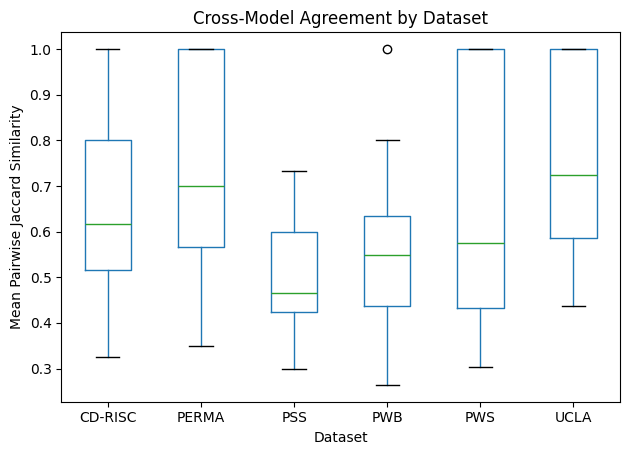

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

agreement_df.boxplot(
    column="mean_pairwise_jaccard",
    by="dataset",
    grid=False
)

plt.suptitle("") 
plt.title("Cross-Model Agreement by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Mean Pairwise Jaccard Similarity")

plt.tight_layout()
plt.show()

## 5. High-Confidence Dimension Assignments (Strict Consensus)

While Section 4 demonstrates that dimension assignments are broadly comparable across different LLM-generated definitions, certain questions exhibit partial disagreement due to sensitivity to definition phrasing. To obtain a set of **maximally reliable and interpretable labels**, we introduce a stricter, dimension-wise consensus criterion in this section.

For a given survey question \( q \), let \( D_i(q) \) denote the set of wellness dimensions assigned under the \( i \)-th LLM-generated definition set.  
A dimension \( d \) is considered **high-confidence** for question \( q \) if and only if:

$$
d \in \bigcap_{i=1}^{5} D_i(q)
$$

Only dimensions that appear in the assignments of **all five** LLMs are retained. Questions for which this intersection is empty are excluded from the high-confidence subset.

In [8]:
from utils import compute_consensus_spectrum
high_conf_df = compute_consensus_spectrum(all_results)
print(high_conf_df.keys())
print(high_conf_df.iloc[0].to_dict())
print(len(high_conf_df))
high_conf_df.to_csv("../../results/mapping/v2_5LLM_confidence_agreement.csv", index=False)

Index(['qid', 'dataset', 'text', 'exact_5of5', 'exact_4of5', 'exact_3of5',
       'exact_2of5', 'exact_1of5'],
      dtype='str')
{'qid': 'CD_RISC_1', 'dataset': 'CD-RISC', 'text': 'I am able to adapt when changes occur.', 'exact_5of5': ['Emotional', 'Intellectual'], 'exact_4of5': [], 'exact_3of5': ['Occupational', 'Spiritual'], 'exact_2of5': [], 'exact_1of5': ['Physical', 'Social']}
145


In [9]:
def highest_consensus_level(row, K=5):
    for k in range(K, 0, -1):
        if len(row[f'exact_{k}of{K}']) > 0:
            return k
    return 0

high_conf_df['max_consensus'] = high_conf_df.apply(
    highest_consensus_level, axis=1
)

level_counts = (
    high_conf_df['max_consensus']
    .value_counts()
    .sort_index(ascending=False)
    .reset_index()
)
level_counts.columns = ['consensus_level', 'num_questions']
level_counts['percentage'] = level_counts['num_questions'] / len(high_conf_df)

level_counts

,consensus_level,num_questions,percentage
0,5,114,0.786207
1,4,31,0.213793


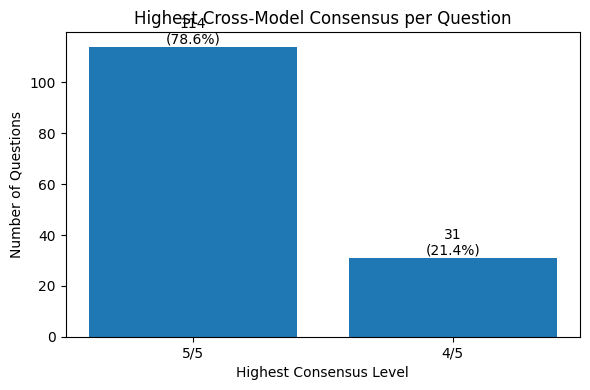

In [10]:
import matplotlib.pyplot as plt

# level_counts already computed
# columns: ['consensus_level', 'num_questions', 'percentage']

# Convert to string labels like "5/5"
level_counts['label'] = level_counts['consensus_level'].astype(str) + '/5'

plt.figure(figsize=(6,4))
bars = plt.bar(
    level_counts['label'],
    level_counts['num_questions']
)

plt.ylabel('Number of Questions')
plt.xlabel('Highest Consensus Level')
plt.title('Highest Cross-Model Consensus per Question')

# Annotate bars with count + percentage
for bar, pct in zip(bars, level_counts['percentage']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}\n({pct:.1%})',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 6. Compare with Human

In [11]:
from utils import compute_distribution_entropy

def convert_to_top1(all_results):
    top1_results = {}

    for model_name, df in all_results.items():
        df = df.copy()

        def pick_top1(row):
            dims = row.get("dimensions", [])
            scores = row.get("scores", [])

            if not isinstance(dims, list) or not isinstance(scores, list):
                return []

            if len(dims) == 0 or len(scores) == 0:
                return []

            idx = int(np.argmax(scores))
            return [dims[idx]]

        df["dimensions"] = df.apply(pick_top1, axis=1)
        df = df.drop(columns=["scores"], errors="ignore")

        top1_results[model_name] = df

    return top1_results


top1_results = convert_to_top1(all_results)

# entropy of mean vote distribution (top1 => vote entropy)
ent_all_result_top1 = compute_distribution_entropy(top1_results)

# optional: rename to keep downstream code unchanged
jsd_all_result_top1 = ent_all_result_top1.rename(
    columns={"entropy": "jsd", "entropy_norm": "jsd_norm"}
)

print(jsd_all_result_top1.head())

jsd_all_result = jsd_all_result_top1
print(jsd_all_result.head())

         qid  dataset                                       text       jsd  \
0  CD_RISC_1  CD-RISC     I am able to adapt when changes occur.  1.370951   
1  CD_RISC_2  CD-RISC  I have one close and secure relationship.  0.721928   
2  CD_RISC_3  CD-RISC            Sometimes fate or God helps me.  0.721928   
3  CD_RISC_4  CD-RISC     I can deal with whatever comes my way.  1.921928   
4  CD_RISC_5  CD-RISC         Past successes give me confidence.  1.370951   

   jsd_norm  
0  0.456984  
1  0.240643  
2  0.240643  
3  0.640643  
4  0.456984  
         qid  dataset                                       text       jsd  \
0  CD_RISC_1  CD-RISC     I am able to adapt when changes occur.  1.370951   
1  CD_RISC_2  CD-RISC  I have one close and secure relationship.  0.721928   
2  CD_RISC_3  CD-RISC            Sometimes fate or God helps me.  0.721928   
3  CD_RISC_4  CD-RISC     I can deal with whatever comes my way.  1.921928   
4  CD_RISC_5  CD-RISC         Past successes give me conf

In [12]:
import pandas as pd
import ast
import numpy as np
from functools import reduce

from utils import compute_distribution_entropy  # <-- use entropy function

# load
human_all_results = pd.read_csv("../../question_database/processed/human_all_results_like.csv")
human_all_results["dimensions"] = human_all_results["dimensions"].apply(ast.literal_eval)

# dict[str, DataFrame] per human
human_results_dict = {
    person: grp[["qid", "dataset", "text", "dimensions"]]
        .drop_duplicates(subset=["qid"])
        .copy()
    for person, grp in human_all_results.groupby("dimension_model")
}

# intersection of qids across all humans
qid_sets = [set(df["qid"]) for df in human_results_dict.values()]
common_qids = sorted(reduce(set.intersection, qid_sets))

# filter each df to common qids
human_results_dict = {
    person: df[df["qid"].isin(common_qids)].copy()
    for person, df in human_results_dict.items()
}

print("common qids:", len(common_qids))
print("num humans:", len(human_results_dict))

# ---------- downsample humans to match 5 LLMs ----------
K = 5       # match 5 LLMs
N = 500     # repeats (200~1000 ok)

people = sorted(human_results_dict.keys())
rng = np.random.default_rng(42)

ent_runs = []
for _ in range(N):
    sampled_people = rng.choice(people, size=K, replace=False)
    sampled_dict = {p: human_results_dict[p] for p in sampled_people}

    ent_df = compute_distribution_entropy(sampled_dict, normalize=True)  # returns entropy_norm
    ent_runs.append(ent_df.set_index("qid")["entropy_norm"])

# stack runs into matrix: index=qid, columns=rep
ent_mat = pd.concat(ent_runs, axis=1)
ent_mat.columns = range(N)

human_entropy_downsampled = pd.DataFrame({
    "qid": ent_mat.index,
    "human_entropy_mean_5": ent_mat.mean(axis=1),
    "human_entropy_median_5": ent_mat.median(axis=1),
    "human_entropy_p10_5": ent_mat.quantile(0.10, axis=1),
    "human_entropy_p90_5": ent_mat.quantile(0.90, axis=1),
}).reset_index(drop=True)

print(human_entropy_downsampled.head())

# keep downstream code unchanged: rename mean entropy_norm -> jsd_norm
human_jsd_all_result = human_entropy_downsampled.rename(
    columns={"human_entropy_mean_5": "jsd_norm"}
)[["qid", "jsd_norm"]]

common qids: 87
num humans: 28
         qid  human_entropy_mean_5  human_entropy_median_5  \
0  CD_RISC_1              0.437818                0.488342   
1  CD_RISC_2              0.125884                0.000000   
2  CD_RISC_3              0.000000                0.000000   
3  CD_RISC_4              0.321362                0.257156   
4  CD_RISC_5              0.394900                0.488342   

   human_entropy_p10_5  human_entropy_p90_5  
0             0.257156             0.684605  
1            -0.000000             0.257156  
2            -0.000000             0.000000  
3            -0.000000             0.542122  
4             0.257156             0.542122  


In [13]:


merged = (
    human_jsd_all_result[["qid", "jsd_norm"]].rename(columns={"jsd_norm": "jsd_human"})
    .merge(
        jsd_all_result[["qid", "jsd_norm"]].rename(columns={"jsd_norm": "jsd_llm"}),
        on="qid",
        how="inner"
    )
)

print(merged.shape)
merged.head()

(87, 3)


,qid,jsd_human,jsd_llm
0,CD_RISC_1,0.437818,0.456984
1,CD_RISC_2,0.125884,0.240643
2,CD_RISC_3,0.000000,0.240643
3,CD_RISC_4,0.321362,0.640643
4,CD_RISC_5,0.394900,0.456984


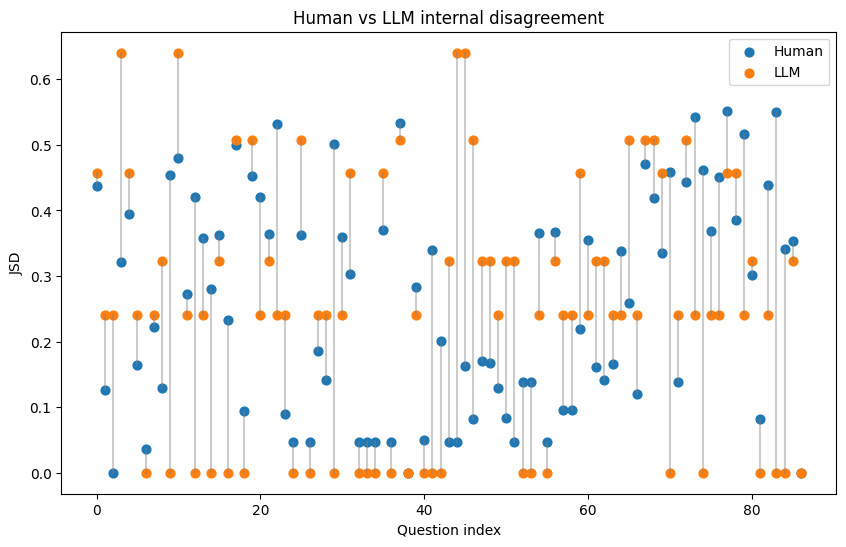

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(merged))

plt.figure(figsize=(10,6))


for i in range(len(merged)):
    plt.plot([i, i],
             [merged["jsd_human"].iloc[i],
              merged["jsd_llm"].iloc[i]],
             color="gray", alpha=0.4)

plt.scatter(x, merged["jsd_human"], label="Human", s=40)
plt.scatter(x, merged["jsd_llm"], label="LLM", s=40)

plt.xlabel("Question index")
plt.ylabel("JSD")
plt.title("Human vs LLM internal disagreement")
plt.legend()

plt.show()

In [15]:
human_avg = merged["jsd_human"].mean()
llm_avg = merged["jsd_llm"].mean()

print("Human avg JSD:", round(human_avg, 4))
print("LLM avg JSD:", round(llm_avg, 4))
print("Difference (Human - LLM):", round(human_avg - llm_avg, 4))

Human avg JSD: 0.2598
LLM avg JSD: 0.247
Difference (Human - LLM): 0.0128


In [16]:
merged["delta"] = merged["jsd_human"] - merged["jsd_llm"]
merged["abs_delta"] = merged["delta"].abs()
top_diff = (
    merged
    .sort_values("abs_delta", ascending=False)
    .head(10)
)

top_diff[["qid", "jsd_human", "jsd_llm", "delta"]]
merged_with_text = merged.merge(
    human_all_results[["qid", "text"]].drop_duplicates(),
    on="qid",
    how="left"
)

top_diff = (
    merged_with_text
    .sort_values("abs_delta", ascending=False)
    .head(10)
)

top_diff[["qid", "text", "jsd_human", "jsd_llm", "delta"]]

,qid,text,jsd_human,jsd_llm,delta
44,PSS_1,"During the past month, what time have you usua...",0.046288,0.640643,-0.594355
83,PWB_18,"I judge myself by what I think is important, n...",0.550398,-0.000000,0.550398
29,PERMA3_3,To what extent do you feel that what you do in...,0.501299,-0.000000,0.501299
45,PSS_3,"During the past month, what time have you usua...",0.163181,0.640643,-0.477461
74,PWB_9,I am good at managing the responsibilities of ...,0.461362,-0.000000,0.461362
70,PWB_5,In many ways I feel disappointed about my achi...,0.458762,-0.000000,0.458762
9,CD_RISC_10,"I make my best effort, no matter what.",0.453790,-0.000000,0.453790
46,PSS_4,"During the past month, how many hours of actua...",0.081511,0.507309,-0.425799
12,CD_RISC_13,"In times of stress, I know where to find help.",0.420327,-0.000000,0.420327
84,PWS_1,I am always optimistic about my future.,0.340661,-0.000000,0.340661


## 7. Human Internal JSD

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR = Path("../../question_database/processed")
df = pd.read_csv(OUT_DIR / "human_repeated_answers_long.csv")

# --- JSD helper ---
def jsd(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / (p.sum() + eps)
    q = q / (q.sum() + eps)
    m = 0.5 * (p + q)

    def kl(a, b):
        a = np.clip(a, eps, 1.0)
        b = np.clip(b, eps, 1.0)
        return np.sum(a * np.log(a / b))

    jsd_nat = 0.5 * kl(p, m) + 0.5 * kl(q, m)
    return jsd_nat / np.log(2) 

# fixed label order (make sure matches your 8 dims)
LABELS = ["Emotional","Physical","Social","Spiritual","Intellectual","Occupational","Environmental","Financial"]

def dist_from_answers(ans_series):
    counts = ans_series.value_counts()
    return np.array([counts.get(l, 0) for l in LABELS], dtype=float)

# --- compute per-qid JSD between repeated versions ---
rows = []
for qid, g in df.groupby("qid"):
    # group by the question version (text column)
    texts = list(g["text"].dropna().unique())
    if len(texts) < 2:
        continue  # no repeated version to compare

    # build distribution per text-version
    dists = {}
    for t in texts:
        dists[t] = dist_from_answers(g.loc[g["text"] == t, "answer"])

    # compute all pairwise jsd between versions, then average
    jsds = []
    for i in range(len(texts)):
        for j in range(i+1, len(texts)):
            jsds.append(jsd(dists[texts[i]], dists[texts[j]]))

    rows.append({
        "qid": qid,
        "n_versions": len(texts),
        "pairwise_jsd_mean": float(np.mean(jsds)),
        "pairwise_jsd_max": float(np.max(jsds)),
    })

qid_jsd = pd.DataFrame(rows).sort_values("pairwise_jsd_mean", ascending=False).reset_index(drop=True)

display(qid_jsd.head(20))
print("avg JSD across repeated qids:", qid_jsd["pairwise_jsd_mean"].mean())

qid_jsd.to_csv(OUT_DIR / "human_repeat_qid_jsd.csv", index=False)
print("Saved:", OUT_DIR / "human_repeat_qid_jsd.csv")

,qid,n_versions,pairwise_jsd_mean,pairwise_jsd_max
0,PWB_9,5,0.057524,0.107821
1,PWB_4,5,0.056288,0.096836
2,PWB_6,5,0.045477,0.072420
3,PWB_2,5,0.043370,0.088938
4,PWB_1,4,0.042170,0.056040
5,CD_RISC_22,3,0.041521,0.060496
6,PWB_10,5,0.038214,0.064652
7,PWB_3,5,0.035430,0.080561
8,PWB_8,5,0.032334,0.057457
9,PWB_5,5,0.031987,0.056252


avg JSD across repeated qids: 0.041035913357681815
Saved: ../../question_database/processed/human_repeat_qid_jsd.csv


In [22]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path
from semantic_mapper import SemanticMapper

# --------------------
# config
# --------------------
IN_PATH = Path("../../question_database/processed/human_repeated_answers_long.csv")
OUT_DIR = Path("../../question_database/processed/llm_repeat_like_human")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DELTA = 0.05
EMB_MODEL = "all-MiniLM-L6-v2"

# --------------------
# utils
# --------------------
def _to_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                return ast.literal_eval(x)
            except Exception:
                return None
    return None

def pick_top1(row):
    dims = _to_list(row.get("dimensions", None))
    scores = _to_list(row.get("scores", None))

    if not dims:
        return None

    # if scores exist, use argmax
    if scores:
        n = min(len(dims), len(scores))
        if n == 0:
            return None
        idx = int(np.argmax(np.array(scores[:n], dtype=float)))
        return dims[idx]

    # fallback: assume dims already ordered by score
    return dims[0]

# --------------------
# load repeated human questions
# --------------------
df_rep = pd.read_csv(IN_PATH)

questions = (
    df_rep[["qid", "text"]]
      .drop_duplicates()
      .reset_index(drop=True)
      .copy()
)
questions["dataset"] = "HUMAN_REPEAT"
questions["text_raw"] = questions["text"]

print("num repeated question versions:", len(questions))

# --------------------
# run mapping
# --------------------
mapper = SemanticMapper(model=EMB_MODEL)
mapper.set_questions_df(questions)

llm_rows = []

for model_name, dim_list in dimension_sets.items():
    mapper.set_dimensions(dim_list, dimension_model_name=model_name)
    df_map = mapper.map_questions_to_dimensions(delta=DELTA)

    # compute top1
    df_map = df_map.copy()
    df_map["answer"] = df_map.apply(pick_top1, axis=1)

    # keep only needed format
    out = df_map[["qid", "text", "answer"]].copy()
    out["source"] = model_name

    # drop rows where top1 failed
    out = out.dropna(subset=["answer"])

    llm_rows.append(out)

df_llm_like_human = pd.concat(llm_rows, ignore_index=True)
display(df_llm_like_human.head())

out_path = OUT_DIR / "llm_repeated_answers_long.csv"
df_llm_like_human.to_csv(out_path, index=False)
print("Saved:", out_path)

num repeated question versions: 52


,qid,text,answer,source
0,CD_RISC_22,I feel like I am in control.,Financial,ChatGPT-5.2
1,CD_RISC_22,I feel like I am in control.2,Social,ChatGPT-5.2
2,CD_RISC_22,I feel like I am in control.3,Social,ChatGPT-5.2
3,PWB_1,I like most parts of my personality.,Social,ChatGPT-5.2
4,PWB_1,I like most parts of my personality.2,Social,ChatGPT-5.2


Saved: ../../question_database/processed/llm_repeat_like_human/llm_repeated_answers_long.csv
